##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Generate and edit videos with Gemini Omni Flash 1.1

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_Omni.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
<a target="_blank" href="https://github.com/google-gemini/cookbook/blob/main/quickstarts/Get_started_Omni.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View on GitHub</a>

Gemini Omni Flash 1.1 (`gemini-omni-1.1-flash`) is a high-performance multimodal model designed for fast, conversational video generation, editing, and cinematic control.
Gemini Omni Flash 1.1 completely replaces previous versions of Gemini Omni Flash, offering enhanced generation quality, native multimodality, and stateful video editing capabilities via the **Interactions API**:

*   **Native multimodality**: Simultaneously processes text, image, audio, and video for cohesive and consistent motion.
*   **Conversational editing**: Iterate and refine video scenes across conversation turns using `previous_interaction_id`.
*   **World knowledge**: Leverages Gemini's deep physical, scientific, and cultural understanding to tell rich visual stories.


## Setup

### Install SDK

The Interactions API requires the latest `google-genai` SDK.

In [ ]:
%pip install -U -q "google-genai>=2.10.0" # 2.10 is needed for the task parameter

To run the following cells, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you do not have an API key yet, create one in [Google AI Studio](https://aistudio.google.com/). For detailed instructions on API keys and authentication, see the [Authentication guide](./Authentication.ipynb).

In [ ]:
from google import genai
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

Select the model you want to use in this guide:

In [ ]:
MODEL_ID = "gemini-omni-1.1-flash"  # @param ["gemini-omni-1.1-flash", "gemini-omni-flash-preview"] {"allow-input": true, "isTemplate": true}


## Generate videos with Omni

To generate a video purely from text instructions, call `client.interactions.create` with `model=MODEL_ID` and specify `"type": "video"` inside `response_format`:

In [ ]:
interaction = client.interactions.create(
    model=MODEL_ID,
    input="A golden retriever running joyfully through a field of wildflowers at sunset.",
    response_format={"type": "video"},  # Optionnal
)

### Understanding API Outputs & The `.output_video` Shortcut

When you call `client.interactions.create(...)`, the API returns an `Interaction` response object. Because Omni is natively multi-modal and structured around conversational turns, the response contains an ordered sequence of **`steps`** representing the model's execution trajectory.

In [ ]:
import json

# Trim 'data' and 'signature' fields across all steps and nested content parts
print(json.dumps([
    {**s.__dict__,
     **{k: v[:70] + '... (trimmed)' for k, v in s.__dict__.items() if k in ['data', 'signature'] and isinstance(v, str) and len(v) > 100},
     'content': [{**c.__dict__,
                  **{k: v[:70] + '... (trimmed)' for k, v in c.__dict__.items() if k == 'data' and isinstance(v, str) and len(v) > 100}}
                 for c in getattr(s, 'content', []) or []]}
    for s in interaction.steps
], indent=2))

[
  {
    "type": "thought",
    "signature": "EpcwCpQwAQw51sdIHNZALkCs5IRZCnpYdhlELCSywDOHgqahPhmAsSLONU9GcNCGhR5dhN... (trimmed)",
    "summary": null,
    "content": []
  },
  {
    "type": "model_output",
    "content": [
      {
        "type": "video",
        "data": "AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAABf5dXVpZNj+w9YbDkg8kpdYKI... (trimmed)",
        "uri": null,
        "mime_type": "video/mp4",
        "resolution": null
      }
    ],
    "error": null
  }
]


### Traversing output steps
Each step in `interaction.steps` has a `type`:
*   `thought`: Contains reasoning summaries when thinking is enabled.
*   `model_output`: Contains the final generated media content.

Inside a `model_output` step, `step.content` is a list of media parts (`text`, `image`, `audio`, or `video`). You can manually traverse these parts to inspect metadata or extract video bytes:

In [ ]:
from IPython.display import Video, display

# Manually loop through steps to find the video part
for step in reversed(interaction.steps):
    if step.type == "model_output" and step.content:
        for part in reversed(step.content):
            if part.type == "video":
                display(Video(data=part.data, embed=True, mimetype=part.mime_type))
                break

### The `.output_video` convenience property
To simplify onboarding and everyday scripting, the `google-genai` SDK provides a direct shortcut property `.output_video` on the interaction response which always contains the last video generated:

In [ ]:
# Access the generated video directly without inspecting steps
video_part = interaction.output_video
print(video_part.mime_type)  # e.g., 'video/mp4'
display(Video(data=video_part.data, embed=True, mimetype=video_part.mime_type))

video/mp4


To simplify the next code blocks, let's define helper functions using `IPython.display.Video` and `Markdown`:

In [ ]:
# @title Display helpers
import base64
from IPython.display import Image, Markdown, Video, display


def get_output_video(interaction):
    """Retrieve the video part using .output_video or manual traversal."""
    if hasattr(interaction, "output_video") and interaction.output_video:
        return interaction.output_video
    if hasattr(interaction, "steps") and interaction.steps:
        for step in reversed(interaction.steps):
            if step.type == "model_output" and step.content:
                for content in reversed(step.content):
                    if content.type == "video":
                        return content
    return None


def get_output_image(interaction):
    """Retrieve the image part using .output_image or manual traversal."""
    if hasattr(interaction, "output_image") and interaction.output_image:
        return interaction.output_image
    if hasattr(interaction, "steps") and interaction.steps:
        for step in reversed(interaction.steps):
            if step.type == "model_output" and step.content:
                for content in reversed(step.content):
                    if content.type == "image":
                        return content
    return None


def show_video(interaction, width=640):
    """Render a video output inline in Colab using Video()."""
    output = get_output_video(interaction)
    if output is None or not getattr(output, "data", None):
        print("No video content found in interaction.")
        return
    mime = getattr(output, "mime_type", "video/mp4") or "video/mp4"
    display(Video(data=output.data, embed=True, mimetype=mime))


def show_thoughts(interaction):
    """Extract and display model thinking summaries formatted as Markdown."""
    if not hasattr(interaction, "steps") or not interaction.steps:
        return
    for step in interaction.steps:
        if step.type == "thought" and getattr(step, "summary", None):
            summary_items = step.summary
            if not isinstance(summary_items, list):
                summary_items = [summary_items]
            for item in summary_items:
                text = getattr(item, "text", str(item))
                display(Markdown(f"**🤔 Thought Summary:**\n\n{text}"))

### Managing Model Thinking & Reasoning

Gemini Omni Flash incorporates internal reasoning to plan physics, lighting, object interactions, and cinematic timing before synthesizing frames. You can manage thinking behavior inside `generation_config`:

*   **Enabling/controlling level**: Set `thinking_level` to `'low'` or `'high'` depending on task complexity. Setting `thinking_level='low'` effectively disables deep active reasoning (though minimal internal trajectory planning still occurs), while `'high'` enables full multi-step reasoning.
*   **Showing summaries**: Pass `thinking_summaries="auto"` to instruct the API to return a structured summary of the model's thought process inside a `thought` step.

Test generating a scientifically accurate stop-motion video with high reasoning enabled:

In [ ]:
thinking_prompt = """
    claymation explainer of protein folding, everything is made out of clay,
    no hands, stop motion, accurate
"""

interaction_thinking = client.interactions.create(
    model=MODEL_ID,
    input=thinking_prompt,
    generation_config={
        "thinking_level": "high",
        "thinking_summaries": "auto",
    },
)

show_thoughts(interaction_thinking)
show_video(interaction_thinking)

**🤔 Thought Summary:**

**Conceptualize a Protein Animation**

I will create a stop-motion claymation video illustrating protein folding. It begins with amino acids forming a chain, transitioning to alpha helices and beta sheets. Next, the structure becomes a complex 3D shape with interactions shown as colored clay balls. Finally, a molecule fits into the structure, highlighting its function. The audio will feature an educational voiceover, playful music, and relevant sound effects.




### Control aspect ratio

By default, Omni generates videos in standard 16:9 widescreen format. You can generate vertical videos for mobile or social feeds by setting `aspect_ratio` to `"9:16"` inside `response_format`:

In [ ]:
portrait_prompt = """
    A futuristic cyberpunk street corner at night with glowing neon rain, reflections on
    wet pavement, and flying vehicles passing overhead. Cinematic vertical establishing shot.
"""

interaction_portrait = client.interactions.create(
    model=MODEL_ID,
    input=portrait_prompt,
    response_format={
        "type": "video",  # optionnal
        "aspect_ratio": "9:16",
    },
)

show_video(interaction_portrait, width=360)

### Resolution controls

Set the `resolution` parameter in `response_format` to control video quality and speed:

*   **360p Draft mode**: Generates lightweight preview clips roughly 2x faster with reduced token consumption.
*   **High resolution (`1080p`, `4k`)**: Generates crisp high-resolution videos.


In [ ]:
# Generate high-resolution (1080p) video with URI delivery
interaction_1080p = client.interactions.create(
    model=MODEL_ID,
    input="A cinematic drone shot gliding smoothly through misty pine mountains at sunrise.",
    response_format={
        "type": "video",
        "resolution": "1080p",  # Supported values: "360p", "720p", "1080p", "4k"
        "delivery": "uri"
    }
)

print(f"1080p Video Requested: {interaction_1080p.id}")


### World knowledge
Here is an example demonstrating deep world knowledge and scientific stop-motion accuracy:

In [ ]:
world_knowledge_prompt = """
    The video shows items of the alphabet. An unusual item starting with each
    letter is shown sitting on a table (like a Capybara for C, disco globe for D
    and Lava Lamp for L). Show 3 to 5 letters at the same time, then move to the
    next group. All 26 letters must be represented by 26 items with matching lower
    thirds displaying the letter. Rapid fire, roughly 9 frames per item at 24FPS.
    Accompanied by calm smooth music.
"""

interaction_wk = client.interactions.create(
    model=MODEL_ID,
    input=world_knowledge_prompt,
)

show_video(interaction_wk)

## Image-to-Video

### Generating reference images

Instead of relying on external files or rudimentary graphics, you can use Gemini's image generation model (**Nano-Banana 2 Lite**, via `gemini-3.1-flash-image`) to quickly generate high-quality custom 16:9 reference artwork:

**Generated 16:9 Nano-Banana Reference Image:**

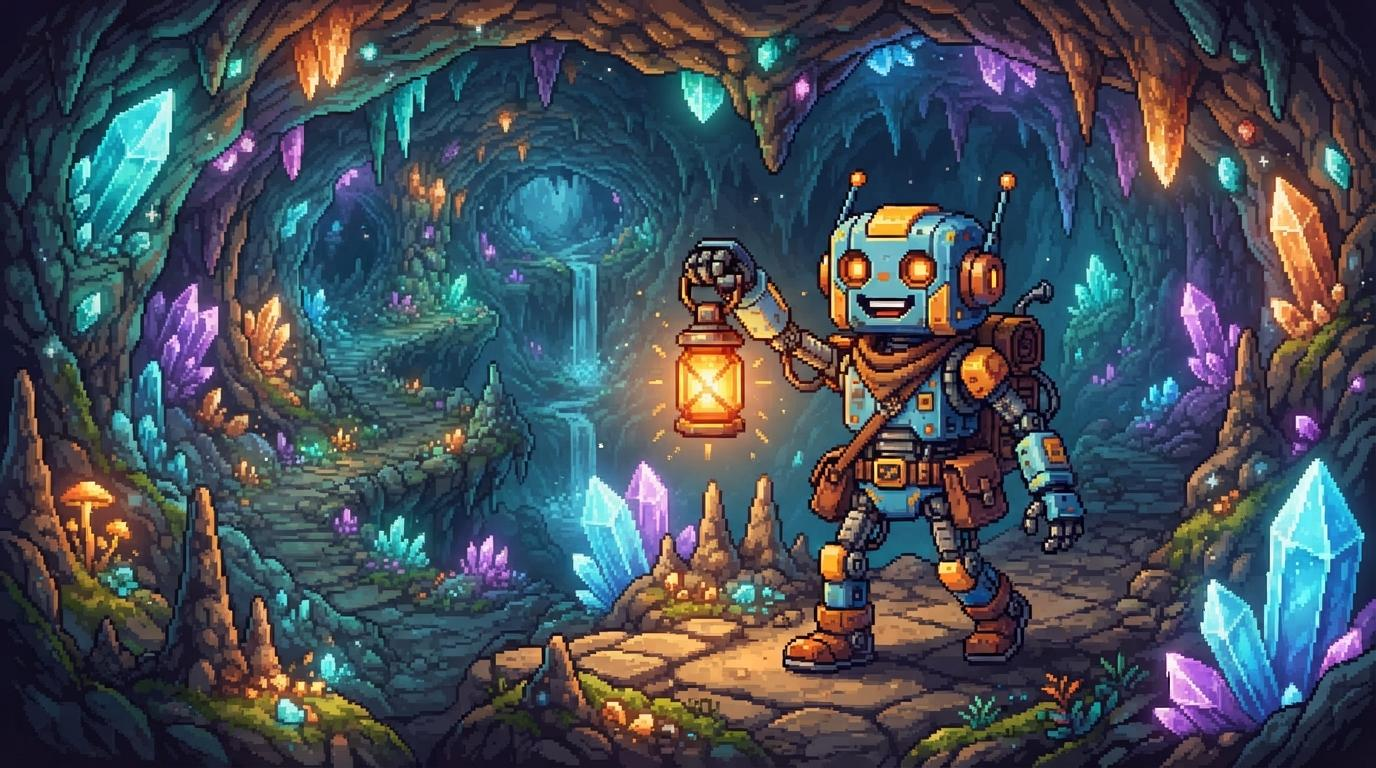

In [ ]:
prompt = "Create a vibrant, detailed pixel art illustration of a cheerful robot adventurer holding a glowing amber lantern in an ancient crystal cavern." # @param {type:"string"}

# Generate a custom 16:9 reference image using Nano-Banana
interaction_img = client.interactions.create(
    model="gemini-3.1-flash-image",
    input=prompt,
    response_modalities=["image"],
    generation_config={"image_config": {"aspect_ratio": "16:9"}},
)

# Extract image using .output_image or helper
image_part = get_output_image(interaction_img)

display(Markdown("**Generated 16:9 Nano-Banana Reference Image:**"))
if isinstance(image_part.data, str):
    display(Image(data=base64.b64decode(image_part.data)))
else:
    display(Image(data=image_part.data))

### Image-to-video (first frame)

To create a video that starts from the custom image you generated, pass both the image and your animation instructions into `input`.

Notice that `input` is structured as a list of dictionaries with different types (`{"type": "image", ...}` paired with `{"type": "text", ...}`). This multi-modal input list enables you to combine explicit visual starting compositions with natural language animation instructions simultaneously:

In [ ]:
animate_prompt = "Animate the robot raising its lantern high as shimmering crystal dust swirls gently around the cavern." # @param {type:"string"}

interaction_i2v = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {
            "type": "text",
            "text": animate_prompt,
        },
    ],
)

show_video(interaction_i2v)

### Direct Multi-Turn Transition from Nano-Banana to Omni

Because Nano-Banana (`gemini-3.1-flash-image`) and Omni Flash share the unified Interactions API, you can skip extracting raw image bytes altogether. Instead, pass `previous_interaction_id=interaction_img.id` directly into Omni Flash to smoothly animate the image created in your previous turn:

In [ ]:
animate_prompt = "Everything shakes as the cavern crumbles and and a dragon wakes up." # @param {type:"string"}

# Transition directly from Nano-Banana interaction_img.id into Omni Flash
interaction_nb_turn = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=interaction_img.id,
    input=animate_prompt,
)

show_video(interaction_nb_turn)

### Reference(s)-to-video

In Reference-to-Video workflows, the provided image is **not** used as the literal starting frame. Instead, the model extracts the subject, character identity, or artistic composition and embeds it into a completely different environment or camera perspective.

In this example, notice how our Nano-Banana robot illustration is extracted as a reference subject and depicted as a framed painting hanging inside a cozy Victorian room:

In [ ]:
ref_prompt = "A continuous handheld shot moving slowly through a cozy Victorian study with warm fireplace lighting. Hanging framed on the wooden wall is a painting depicting the exact scene from the reference image." # @param {type:"string"}

interaction_ref = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": ref_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_ref)

### Keyframe interpolation

Generate continuous video that smoothly transitions between a starting frame and an ending frame. This is ideal for camera orbits, zoom effects, timelapse progressions, and seamless looping clips.


In [ ]:
# Keyframe interpolation with start and end frames
# The task parameter is optional. If omitted, the model automatically infers the mode.
interaction_interp = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": "Smooth continuous timelapse from sunrise to sunset over a mountain lake."}
    ],
    generation_config={
        "video_config": {
            "task": "image_to_video"
        }
    },
    response_format={"type": "video"}
)

print(f"Interpolation Interaction ID: {interaction_interp.id}")


### Advanced: Controlling Starting Frames vs. References (`task` parameter)

When given both images and text, Omni Flash infers whether to use an image as the literal opening frame (`image_to_video`) or as an indirect style/subject reference (`reference_to_video`). Occasionally, ambiguous multi-modal prompts can cause the model to mistake a reference image for a literal starting frame.

To guarantee precise execution in production pipelines, explicitly set the `task` parameter inside `generation_config.video_config` to either `"image_to_video"` or `"reference_to_video"`.

> **Important Note:** Specifying an explicit `task` parameter forces a standalone generation workflow and prevents you from chaining edits using `previous_interaction_id`.

In [ ]:
# Explicit task parameter example
task_prompt = "A dragon's lair, but who's footsteps do we hear?" # @param {type:"string"}
interaction_task = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": task_prompt},
    ],
    generation_config={"video_config": {"task": "image_to_video"}},
)

show_video(interaction_task)

In [ ]:
# Explicit task parameter example
task_prompt = "A dragon's lair, but who's footsteps do we hear?" # @param {type:"string"}
interaction_task = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": task_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_task)

### Advanced: Use reference tags to control complex examples

For intricate multi-subject scenes, use explicit reference tags inside your text prompt to bind specific uploaded images to distinct roles:
*   `<FIRST_FRAME>`: Binds the image as the exact opening frame of the clip.
*   `<IMAGE_REF_0>`, `<IMAGE_REF_1>`, etc.: Binds images (0-indexed matching the order in `input`) to specific character identities, objects, or wardrobe items.

Omni Flash supports combining up to 5 reference images in a single call. Use Nano-Banana 2 Lite (`gemini-3.1-flash-image`) below to generate 3 distinct characters alongside 3 matching accessories (6 images total), and then combine them into a unified campfire scene where each character wears their matching accessory:

**6 Nano-Banana Reference Images (3 Characters + 3 Accessories):**

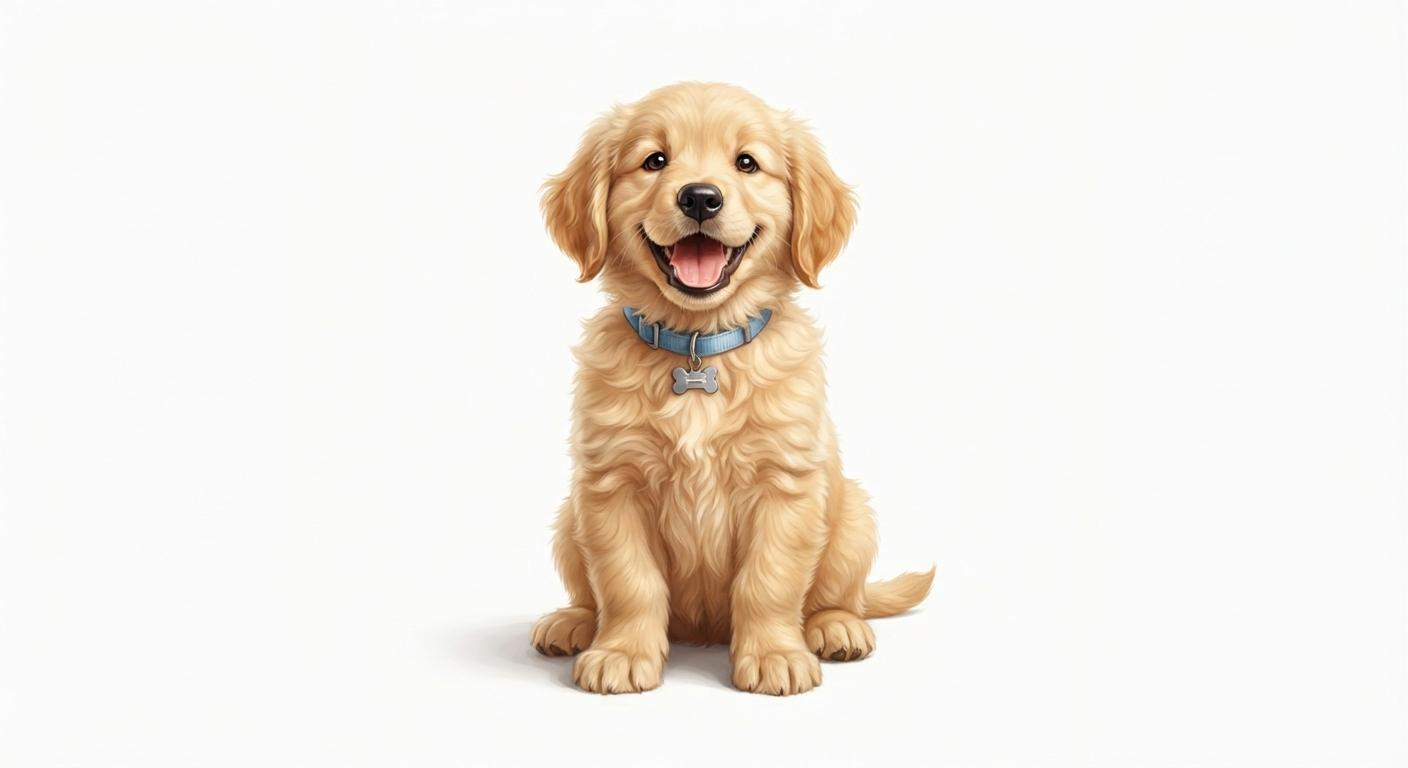

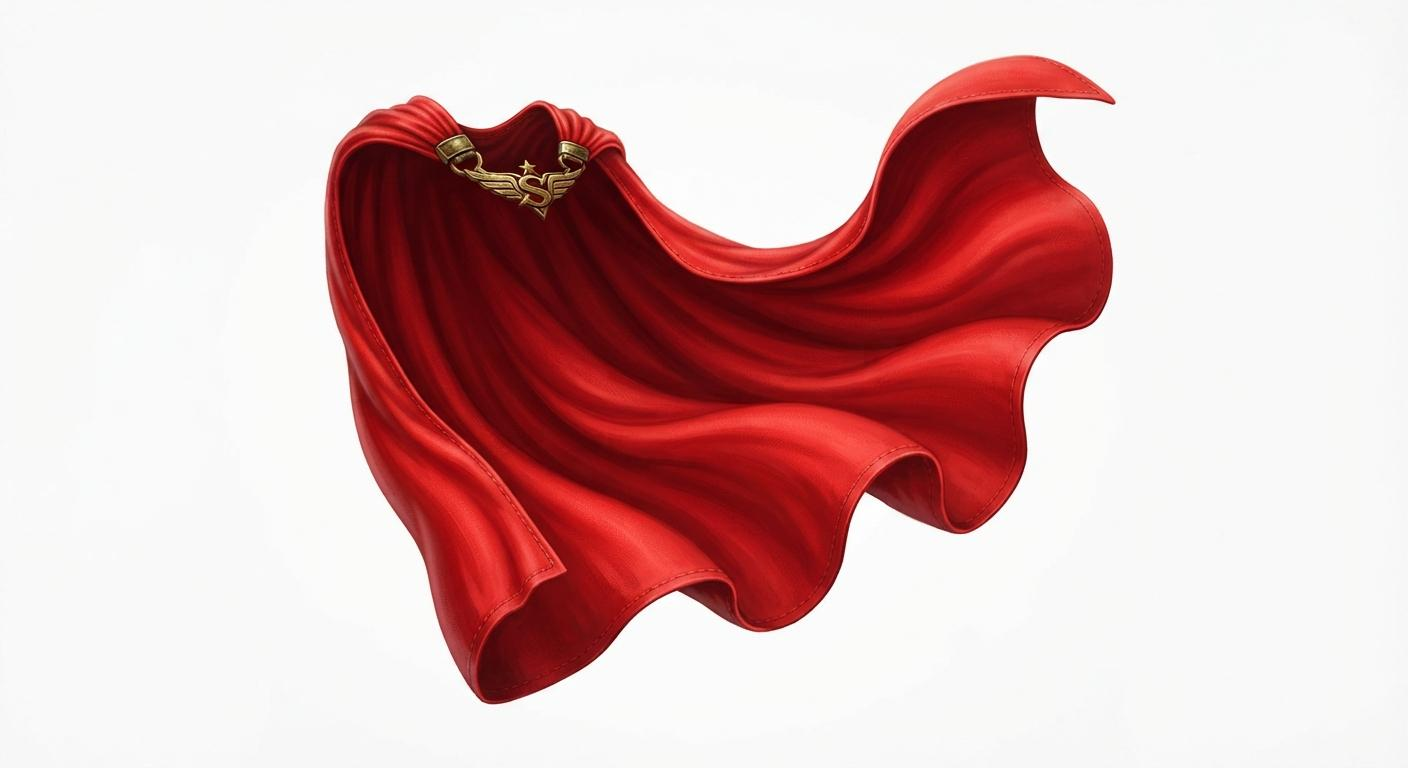

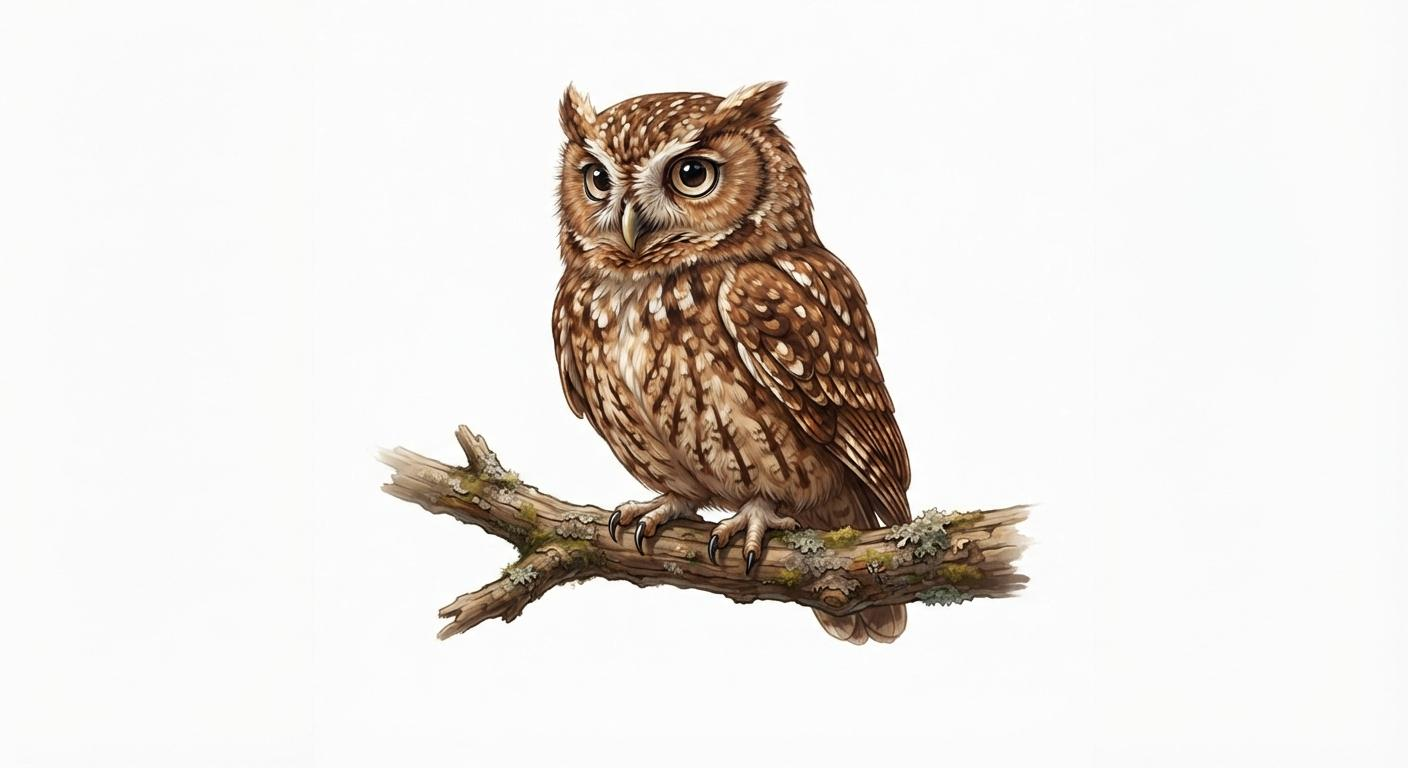

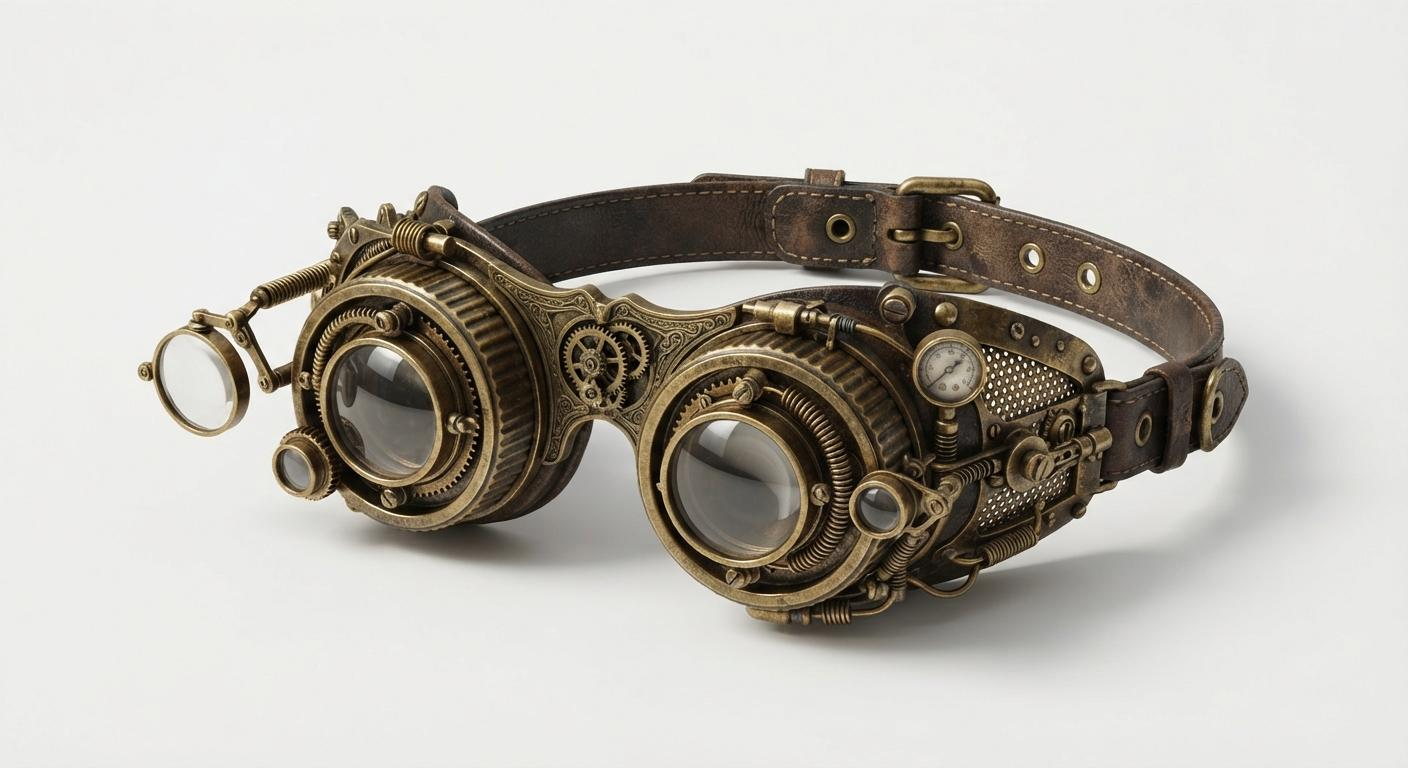

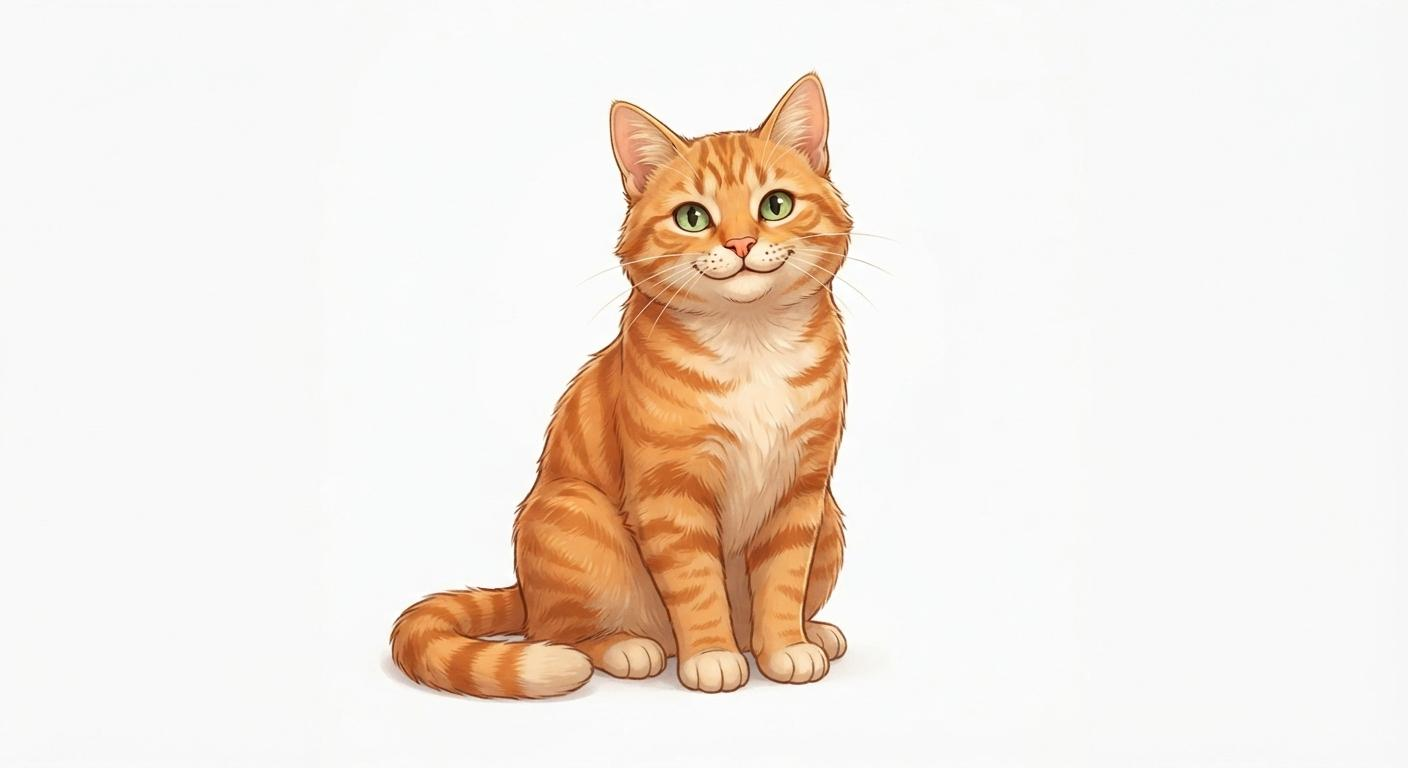

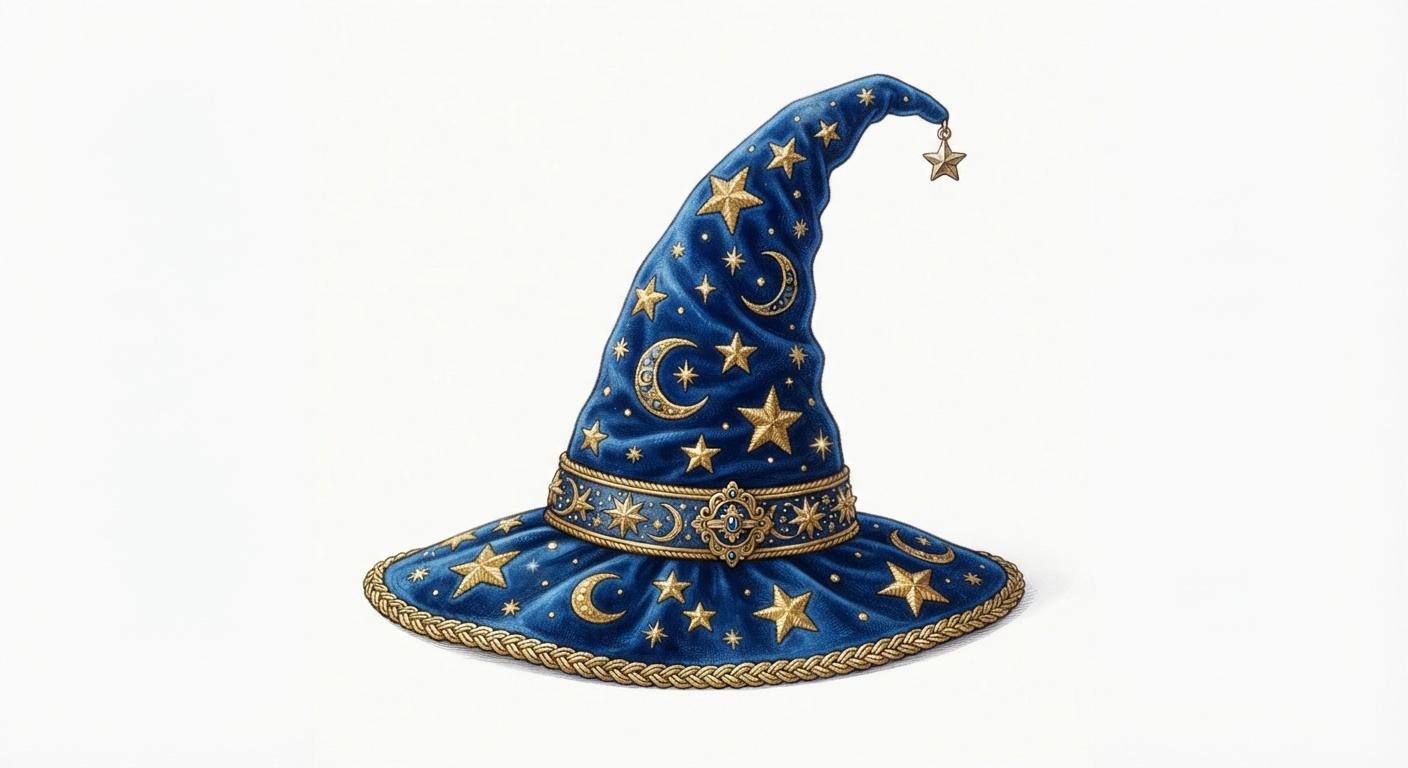

In [ ]:
# Generate 3 distinct characters and 3 matching accessories using Nano-Banana
char1 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed digital illustration of a cheerful golden retriever puppy sitting happily on a plain white background.", response_modalities=["image"])
acc1 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed illustration of a flowing bright red superhero cape on a plain white background.", response_modalities=["image"])
char2 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed digital illustration of a wise little brown owl perched on a plain white background.", response_modalities=["image"])
acc2 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed illustration of antique brass steampunk goggles on a plain white background.", response_modalities=["image"])
char3 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed digital illustration of a friendly orange tabby cat sitting on a plain white background.", response_modalities=["image"])
acc3 = client.interactions.create(model="gemini-3.1-flash-image", input="Create a detailed illustration of a pointed blue wizard hat decorated with golden stars on a plain white background.", response_modalities=["image"])

img_c1, img_a1 = get_output_image(char1), get_output_image(acc1)
img_c2, img_a2 = get_output_image(char2), get_output_image(acc2)
img_c3, img_a3 = get_output_image(char3), get_output_image(acc3)

def to_bytes(part):
    return base64.b64decode(part.data) if isinstance(part.data, str) else part.data

display(Markdown("**6 Nano-Banana Reference Images (3 Characters + 3 Accessories):**"))
display(Image(data=to_bytes(img_c1)))
display(Image(data=to_bytes(img_a1)))
display(Image(data=to_bytes(img_c2)))
display(Image(data=to_bytes(img_a2)))
display(Image(data=to_bytes(img_c3)))
display(Image(data=to_bytes(img_a3)))

Combine all six references into a unified scene using tags `<IMAGE_REF_0>` through `<IMAGE_REF_5>`:

In [ ]:
multi_char_prompt = """
    In a single unbroken scene around a twilight campfire in a forest:
    <IMAGE_REF_0> is wearing <IMAGE_REF_5>,
    <IMAGE_REF_2> is wearing <IMAGE_REF_3>,
    and <IMAGE_REF_4> is wearing <IMAGE_REF_1>.
    They smile happily together as embers float into the evening sky.
"""

interaction_6refs = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": img_c1.data, "mime_type": img_c1.mime_type},
        {"type": "image", "data": img_a1.data, "mime_type": img_a1.mime_type},
        {"type": "image", "data": img_c2.data, "mime_type": img_c2.mime_type},
        {"type": "image", "data": img_a2.data, "mime_type": img_a2.mime_type},
        {"type": "image", "data": img_c3.data, "mime_type": img_c3.mime_type},
        {"type": "image", "data": img_a3.data, "mime_type": img_a3.mime_type},
        {"type": "text", "text": multi_char_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_6refs)

Notice how Omni Flash precisely bound each uploaded image pair to its respective character and accessory: the golden retriever puppy (`<IMAGE_REF_0>`) is wearing the starry blue wizard hat (`<IMAGE_REF_5>`), the brown owl (`<IMAGE_REF_2>`) is wearing the steampunk goggles (`<IMAGE_REF_3>`), and the orange tabby cat (`<IMAGE_REF_4>`) is wearing the red superhero cape (`<IMAGE_REF_1>`), all interacting naturally in a shared campfire environment without blending identities.

## Video extension

Extend an existing video by generating a seamless continuation at the tail end of the clip. Describe how you want the video to continue in your prompt, for example `"Extend this video"` or `"Continue the scene: the camera pans across the mountains"`. Gemini Omni Flash analyzes up to 10 seconds of prior context to generate a natural 3–10 second continuation while maintaining temporal continuity, character identity, camera momentum, and environmental lighting.

You can extend:
*   **Videos generated by the model (multi-turn)**: Extend a previously generated video by referencing its `previous_interaction_id`.
*   **Uploaded videos**: Provide an uploaded video file (via the Files API) along with your extension prompt.

> ⚠️ **Important: Video extension constraints and guidelines**

> *   **Append only**: Extension is strictly limited to appending to the end of a video. Prepending content or extending the middle of a clip is not supported.
> *   **Duration limit**: Input videos for extension must be **10 seconds or less** in length when uploading (unless extending videos generated by the model in multi-turn).
> *   **Spoken dialogue on uploaded videos**: Currently, you cannot extend an uploaded video where someone is talking to add additional dialogue (it is supported if the character remains silent or if the prompt does not add dialogue).
> *   **Multi-turn voice extension**: Generating spoken dialogue or speech is fully supported when extending previously generated videos via multi-turn (`previous_interaction_id`).
> *   **Regional availability**: Extending uploaded videos is not currently available for users in the European Economic Area (EEA), Switzerland, and the United Kingdom (extending videos generated by the model is supported in all available regions).
> *   **Prompting vs. `task="extend"`**: We recommend relying primarily on natural language prompting. Optionally, you can set `"task": "extend"` under `generation_config.video_config` if prompting alone does not produce the expected extension mode, but note that the explicit `task` field adds strict constraints (such as disabling multimodal reference inputs).


### Example 1: Multi-turn extension (Camera & scene continuation)

First, generate a base video clip. Then, extend the scene across conversation turns by passing `previous_interaction_id`:


In [ ]:
# Generate the base video (Turn 1)
turn1_prompt = "[0-10s] Single unbroken continuous camera shot from a locked perspective gliding forward along a scenic coastal road at sunset. A sleek silver sports car cruises smoothly in front of the camera. Completely continuous unbroken take."  # @param {type:"string"}
turn1 = client.interactions.create(
    model=MODEL_ID,
    input=turn1_prompt,
    response_format={"type": "video"},
)

print("Base Video (Turn 1):")
show_video(turn1)


In [ ]:
# Extend the shot from Turn 1 using prompt-based extension
# The model analyzes the prior interaction and seamlessly appends a continuation
extended_turn2 = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=turn1.id,
    input="Continue the shot: the car turns smoothly onto a scenic coastal bridge at twilight as distant lighthouses begin to glow.",
    response_format={"type": "video"},
)

print(f"Extended Video ID: {extended_turn2.id}")
show_video(extended_turn2)


### Example 2: Multi-turn extension with reference media

Prompt-based extension allows you to provide reference images or reference videos in the `input` array alongside `previous_interaction_id` to introduce new characters, objects, or styles seamlessly into the extended scene:


In [ ]:
# Generate a reference image for an asset or character to introduce
ref_traveler = client.interactions.create(
    model="gemini-3.1-flash-lite-image",
    input="A cheerful traveler with a yellow backpack standing by the side of a coastal highway, plain white background.",
    response_modalities=["image"],
)
traveler_img = ref_traveler.output_image

# Extend the previous video while introducing the reference subject
extended_with_ref = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=extended_turn2.id,
    input=[
        {"type": "image", "data": traveler_img.data, "mime_type": traveler_img.mime_type},
        {"type": "text", "text": "[0-10s] The single continuous tracking shot continues unbroken from the exact same camera perspective behind the car. The silver sports car gently slows down as it approaches the shoulder of the road. Ahead on the roadside, the traveler shown in <IMAGE_REF_0> with her yellow backpack comes into view standing by the railing and waves cheerfully."}
    ],
    response_format={"type": "video"},
)

print(f"Extended with Reference ID: {extended_with_ref.id}")
show_video(extended_with_ref)


### Example 3: Extending an uploaded video file (Files API)

You can also extend your own external or pre-recorded video footage (10 seconds or less) by uploading it via the Files API and passing its URI to the Interactions API:


In [ ]:
import time

# 1. Save and upload a source clip (must be 10 seconds or less)
upload_video_path = "sample_clip.mp4"  # @param {type:"string"}

# Save our base video locally to demonstrate uploading an external file:
with open(upload_video_path, "wb") as f:
    f.write(base64.b64decode(get_output_video(turn1).data))

video_file = client.files.upload(file=upload_video_path)

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = client.files.get(name=video_file.name)

# 2. Extend the uploaded video file
extended_uploaded = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "document", "uri": video_file.uri},
        {"type": "text", "text": "Extend this video: the car accelerates smoothly forward along the empty highway as twilight fades into starry night."}
    ],
    response_format={"type": "video"},
)

print(f"Extended Uploaded Video ID: {extended_uploaded.id}")
show_video(extended_uploaded)


## Multi-Turn Conversational Video Editing

One of Omni's most powerful capabilities is multi-turn conversational video editing. Using the `previous_interaction_id` parameter, you can iteratively refine a generated clip across multiple conversation turns. The model maintains full state context, applying targeted modifications while preserving visual continuity.

Edit the previous video by describing only the changes to make:


In [ ]:
# Edit the previous generation by referencing turn1.id
turn2_prompt = "Change the car color to metallic blue. Keep everything else the same."  # @param {type:"string"}
turn2 = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=turn1.id,
    input=turn2_prompt,
)

print("Turn 2 Video (Edited):")
show_video(turn2)


### Editing Uploaded Videos

You can also edit your own real-world video footage by uploading it via the [Files API](https://ai.google.dev/gemini-api/docs/files) and passing its URI to the Interactions API.

> **Note:** Editing uploaded user videos is not currently available for users in the European Economic Area (EEA), Switzerland, and the United Kingdom (editing AI-generated clips as shown above is supported worldwide).


In [ ]:
import time

file_name = "my_clip.mp4" # @param {type:"string"}

video_file = client.files.upload(file=file_name)

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = client.files.get(name=video_file.name)

interaction_edit = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "document", "uri": video_file.uri},
        {"type": "text", "text": "Change the style of the video for a japanese animation. Keep main subject unchanged."},
    ],
)

show_video(interaction_edit)

## Retrieving Videos via URI Delivery (`delivery="uri"`)

When generating videos in production environments, the key benefit of requesting `delivery="uri"` inside `response_format` is **connection reliability and network resilience**. While standard inline delivery streams base64 data directly to your client, a temporary network interruption or browser tab refresh could interrupt the stream and lose the generated media.

By specifying `delivery="uri"`, the API hosts the finished video securely on Google Cloud storage and returns a persistent file identifier. Your application can poll the processing state and download the video reliably regardless of network drops:

In [ ]:
import time

# 1. Request video with URI delivery for connection resilience
interaction_uri = client.interactions.create(
    model=MODEL_ID,
    input="A sweeping aerial drone shot of snowy mountain peaks at sunrise in a single unbroken scene.",
    response_format={
        "type": "video",
        "delivery": "uri"
    },
)

# 2. Extract file name and poll for ACTIVE state
video_output = interaction_uri.output_video
video_uri = video_output.uri
video_bytes = client.files.download(file=video_uri)
with open("mountain_sunrise.mp4", "wb") as f:
    f.write(video_bytes)

print(f"Downloaded mountain_sunrise.mp4 successfully from {video_uri}.")
display(Video("mountain_sunrise.mp4", embed=True))

Downloaded mountain_sunrise.mp4 successfully from https://generativelanguage.googleapis.com/v1beta/files/mwbiec5quubp:download?alt=media.


## Prompting Guide & Best Practices

To get the most out of Gemini Omni Flash, apply these structured prompting techniques:

### Tip 1: Single scene continuity
By default, Omni may introduce multi-shot cinematic cuts to build narrative dynamism. To force a continuous, single-camera perspective, explicitly specify:
*   `"In a single unbroken scene..."`
*   `"Continuous handheld shot, no scene cuts..."`

In [ ]:
tip1_prompt = "Continuous unbroken handheld shot of an ornate antique golden pocket watch resting on an open leather notebook, its second hand ticking smoothly forward." # @param {type:"string"}

interaction_tip1 = client.interactions.create(
    model=MODEL_ID,
    input=tip1_prompt,
)

show_video(interaction_tip1)

### Tip 2: Negative instructions
If unwanted elements appear, state clear prohibitions directly in natural language:
*   `"No dialogue or voiceover."`
*   `"No text overlay on screen."`

In [ ]:
tip2_prompt = "A peaceful campfire glowing softly in a misty forest at dusk. No dialogue or voiceover. No text overlay on screen." # @param {type:"string"}

interaction_tip2 = client.interactions.create(
    model=MODEL_ID,
    input=tip2_prompt,
    response_format={"type": "video"},
)

show_video(interaction_tip2)

### Tip 3: Concise editing prompts
When performing multi-turn edits, keep instructions simple and surgical. Overly lengthy descriptions can confuse the diffing engine.
*   **Do:** `"Change the car color to metallic blue. Keep everything else the same."`
*   **Don't:** `"In the video showing the silver car driving down the road, please replace the silver paint with a metallic blue shade while making sure..."`

In [ ]:
# Surgical multi-turn edit example
edit_prompt = "Add glowing purple neon underglow lights under the car. Keep everything else the same." # @param {type:"string"}
interaction_edit = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=turn1.id,
    input=edit_prompt,
)
show_video(interaction_edit)

### Tip 4: Timing & Chronological Choreography

You can prompt for actions to occur at specific timestamps inside your video using either natural language descriptions or bracketed timecode syntax (`[0-3s]`, `[3-6s]`). This gives you full directorial control over scene rhythm, pacing, and multi-beat storytelling:

*   **Natural language timing**: `"after 3 seconds, a woman enters the scene"`, `"at 5s the chorus starts in the background audio"`.
*   **Bracketed timecode syntax**: `"[0-3s] A person is walking. [3-6s] They stop and turn around. [6-10s] They start running."`

In [ ]:
timing_prompt = "[0-3s] A continuous handheld shot of a woman in a red coat standing still on a snowy city sidewalk looking forward. [3-6s] She slowly opens a bright yellow umbrella as soft snowflakes fall around her." # @param {type:"string"}

interaction_timing = client.interactions.create(
    model=MODEL_ID,
    input=timing_prompt,
    response_format={"type": "video"},
)

show_video(interaction_timing)

### Tip 5: Key moments understanding

You can also prompt the model to do edit the video when some specific action happens.

In [ ]:
tip5_turn1_prompt = "A person stands in front of a mirror. At 0:05, she touches the mirror then she does it again at 0:07, 0:08 and 0:09" # @param {type:"string"}
tip5_turn1 = client.interactions.create(
    model=MODEL_ID,
    input=tip5_turn1_prompt,
)

print("Turn 1 Video (Base):")
show_video(tip5_turn1)

Turn 1 Video (Base):


In [ ]:
tip5_turn2_prompt = "The style of the video changes every time the person touches the mirror" # @param {type:"string"}
tip5_turn2 = client.interactions.create(
    model=MODEL_ID,
    input=tip5_turn2_prompt,
    previous_interaction_id=tip5_turn1.id,
)

print("Turn 2 Video (Edited):")
show_video(tip5_turn2)

Turn 2 Video (Edited):


## Veo vs. Omni: Choosing the Right Model

Google offers two premier video generation model families: **Gemini Omni Flash** and **Veo**. Understanding their distinct architectures helps you select the right tool for your application.

| Capability | Gemini Omni Flash (`gemini-omni-1.1-flash`) | Veo 3.1 (`veo-3.1-lite-generate-preview`) |
| :--- | :--- | :--- |
| **Primary API** | **Interactions API** (`client.interactions.create`) | **Models API** (`client.models.generate_videos`) |
| **Core Strength** | High-speed conversational editing & multi-modal synthesis | Dedicated studio-grade video generation |
| **Stateful Editing** | ✅ **Yes** (Multi-turn editing via `previous_interaction_id`) | ❌ No (Unary generation per call) |
| **Multi-Image R2V** | ✅ **Up to 5 reference images & 5 audio tracks** | ⚠️ Single image reference / prompt |
| **Motion & Dynamics** | Dynamic, engaging motion and complex storyline pacing | High visual fidelity and cinematic realism |
| **Text Interleaving** | Accurate text rendering on signs/objects within scenes | Strict isolation (no interleaved text overlays) |

### When to prefer Gemini Omni Flash:
*   **Conversational workflows**: Iterative multi-turn editing where users refine clips via dialogue.
*   **Complex reasoning**: Prompts requiring deep world knowledge, physics understanding, or multi-modal fusion.
*   **Rich referencing**: Tasks combining multiple reference characters, product images, and style guides.

### When to continue using Veo:
*   **High-throughput economy**: **Veo 3.1 Lite** offers the most competitive quality-versus-cost trade-off for batch clip generation.
*   **Resolution requirements**: Ultra-high definition 1080p and 4K output pipelines.
*   **Structural video tasks**: Video extension and first-to-last frame interpolation workflows.
*   **Pure clip synthesis**: Automated pipelines requiring standalone B-roll clips without shot cuts or conversational overhead.

## Next Steps

*   Explore the official [Interactions API Overview](https://ai.google.dev/gemini-api/docs/interactions-overview).
*   Read the [Gemini Omni Documentation](https://ai.google.dev/gemini-api/docs/omni) and [Veo Documentation](https://ai.google.dev/gemini-api/docs/veo).
*   Review [Gemini API Pricing](https://ai.google.dev/gemini-api/docs/pricing) for video generation tiers.
*   Check out the [Introduction to Prompt Design](https://ai.google.dev/gemini-api/docs/prompting-intro) for advanced prompting strategies.